In [ ]:
!pip install xgboost

Dataset shape: (5000, 14)
   age  gender  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0   63       1   3       145   233    1        0      150      0      2.3   
1   37       1   2       130   250    0        1      187      0      3.5   
2   41       0   1       130   204    0        0      172      0      1.4   
3   56       1   1       120   236    0        1      178      0      0.8   
4   57       0   0       120   354    0        1      163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  

1) Missing values (count):
age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values (%)
age         0.0
gender      0.0
cp          0.0
trestbps    0.0
chol        0.0


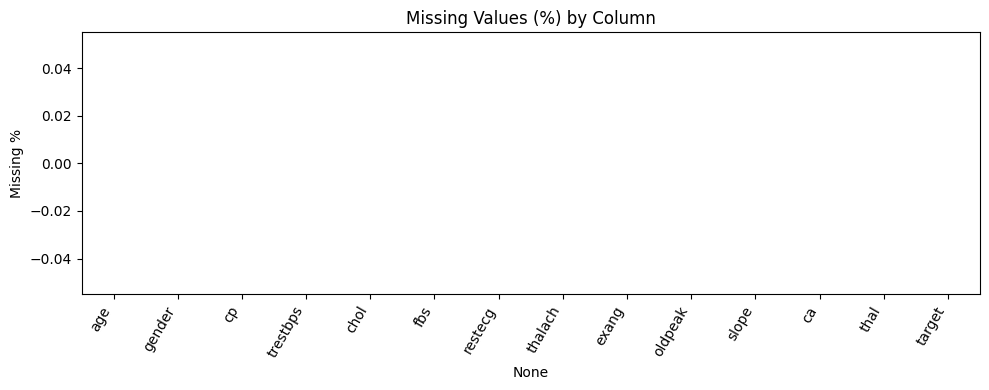


2) Target balance (0=no disease, 1=disease):
target
1    2702
0    2298
Name: count, dtype: int64
target
1    54.04%
0    45.96%
Name: proportion, dtype: object


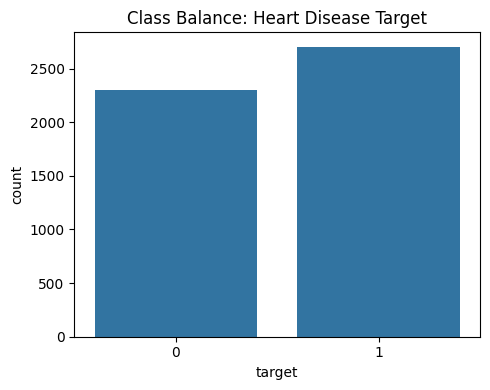

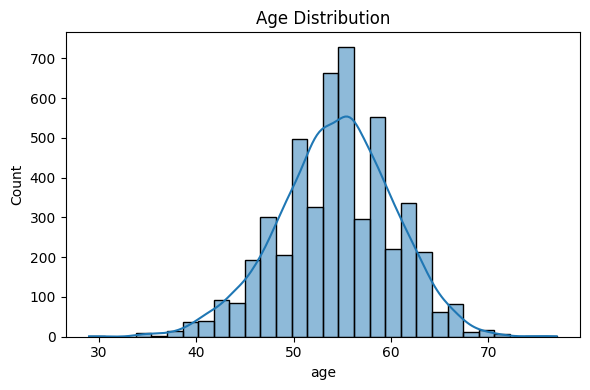

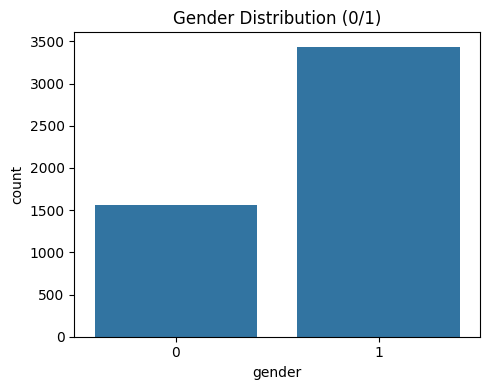

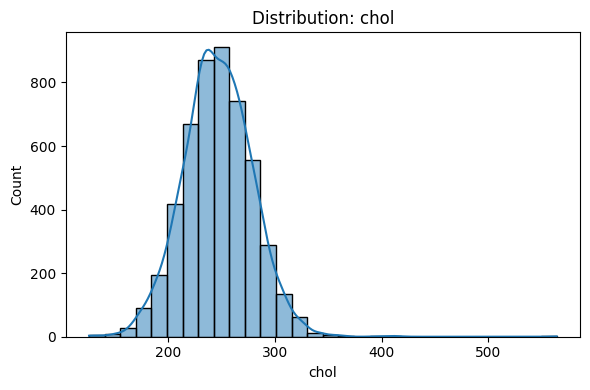

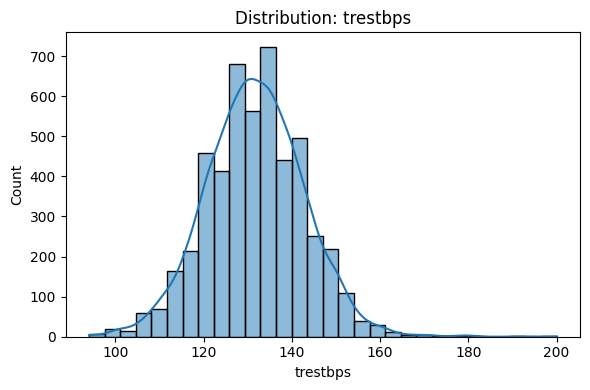

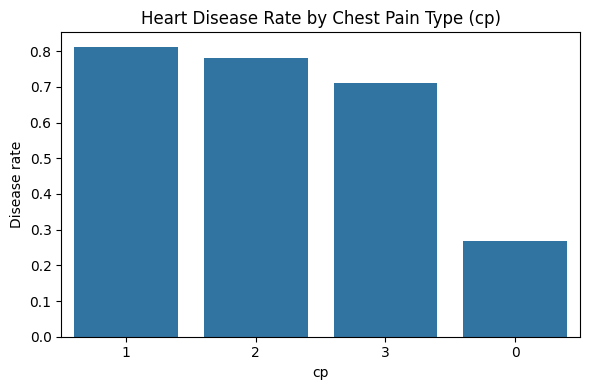

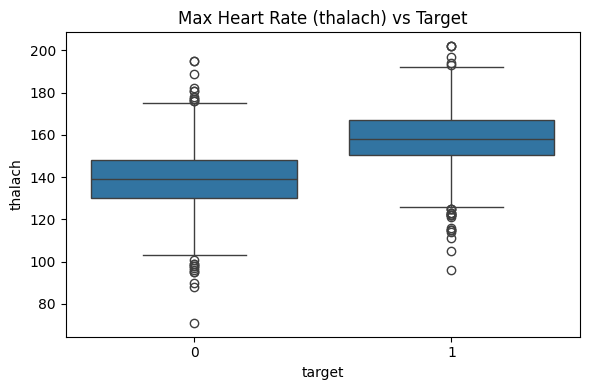

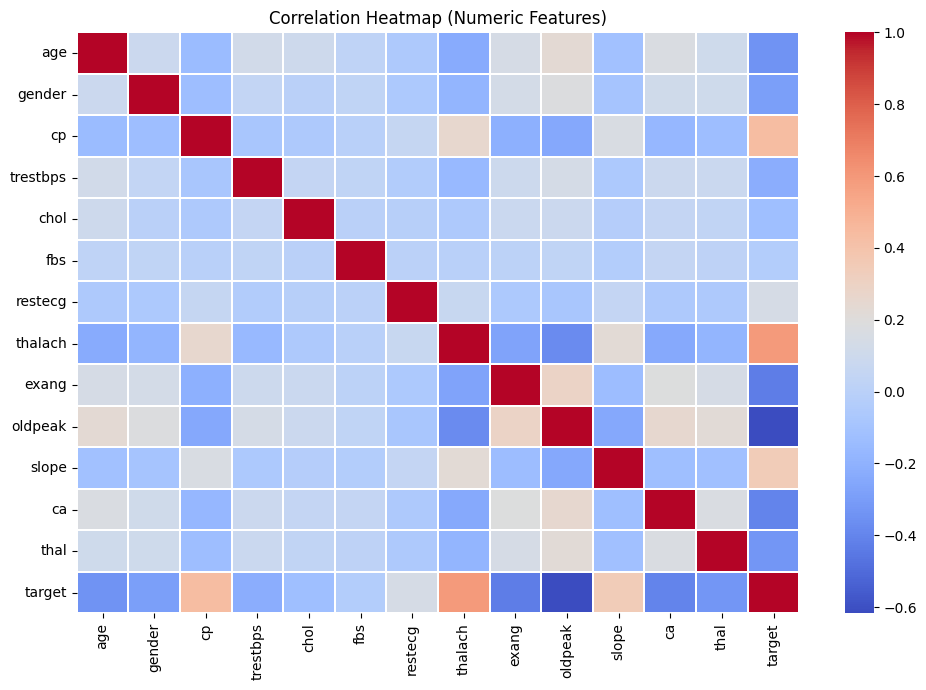

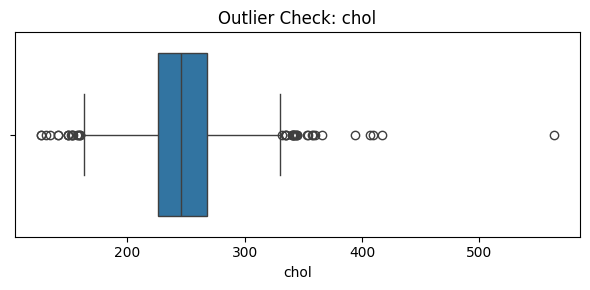

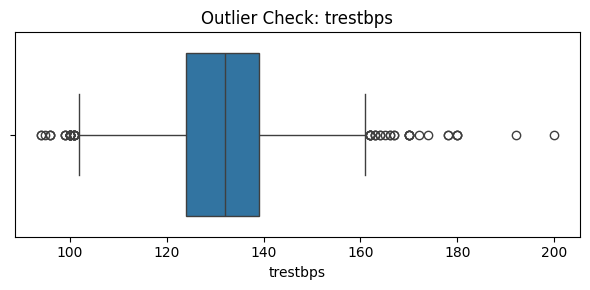

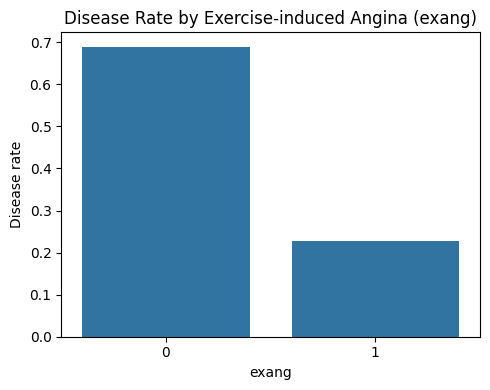

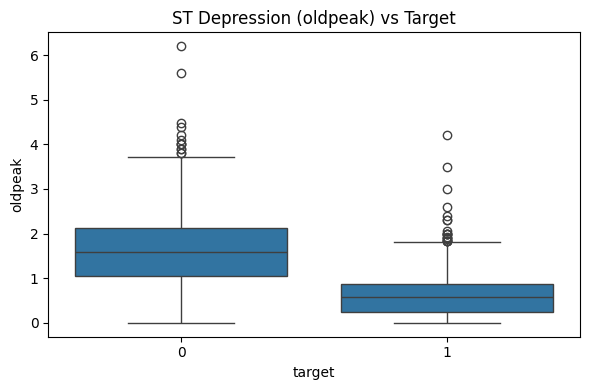


After encoding, X shape: (5000, 22)
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0              XGBoost     0.949   0.965714  0.938889  0.952113  0.990886
1        Random Forest     0.948   0.958647  0.944444  0.951493  0.988007
2  Logistic Regression     0.944   0.960076  0.935185  0.947467  0.986848
3            SVM (RBF)     0.946   0.956767  0.942593  0.949627  0.986320

Best model (by ROC_AUC): XGBoost


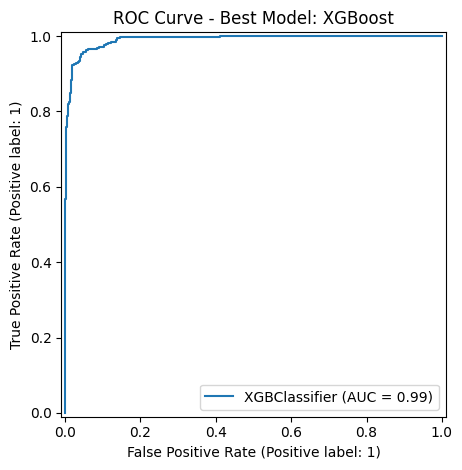


Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       460
           1       0.97      0.94      0.95       540

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


Top 15 Feature Importances:
thal_2      0.168474
oldpeak     0.103622
thalach     0.089421
exang_1     0.089194
slope_2     0.066256
cp_1        0.057683
ca_2        0.054987
cp_2        0.053533
thal_3      0.051493
ca_1        0.045209
gender_1    0.041945
ca_3        0.040913
cp_3        0.035754
age         0.020547
slope_1     0.019161
dtype: float32


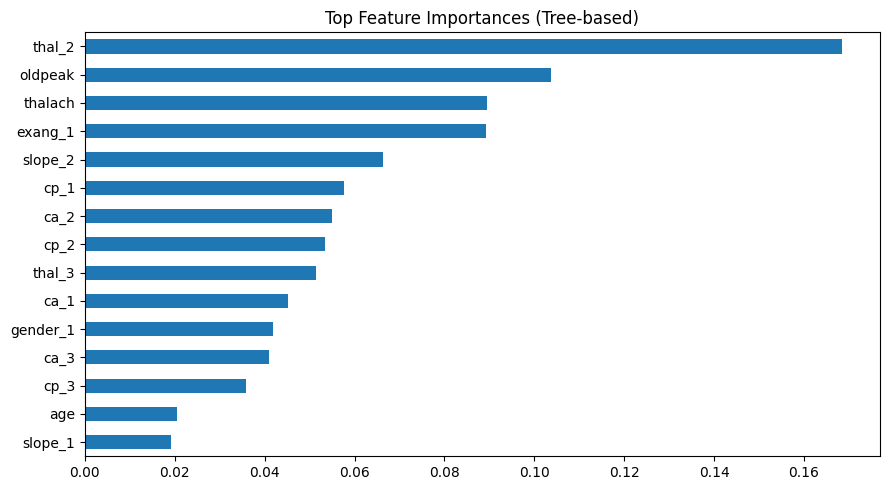

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -----------------
# Load Data
# -----------------
path = "./"
csv_file = "heart_data.csv"
df = pd.read_csv(path + csv_file)

print("Dataset shape:", df.shape)
print(df.head())

# -----------------
# EDA
# -----------------

print("\n1) Missing values (count):")
print(df.isna().sum())

print("\nMissing values (%)")
print((df.isna().mean() * 100).round(2).sort_values(ascending=False))

plt.figure(figsize=(10,4))
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xticks(rotation=60, ha="right")
plt.title("Missing Values (%) by Column")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()

# Target balance
print("\n2) Target balance (0=no disease, 1=disease):")
print(df["target"].value_counts())
print((df["target"].value_counts(normalize=True)
       .mul(100).round(2).astype(str)) + "%")

plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Class Balance: Heart Disease Target")
plt.tight_layout()
plt.show()

# Age distribution
if "age" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["age"], bins=30, kde=True)
    plt.title("Age Distribution")
    plt.tight_layout()
    plt.show()

# Gender distribution
if "gender" in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x="gender", data=df)
    plt.title("Gender Distribution (0/1)")
    plt.tight_layout()
    plt.show()

# Chol & trestbps distribution
for col in ["chol", "trestbps"]:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Distribution: {col}")
        plt.tight_layout()
        plt.show()

# Chest pain vs target
if "cp" in df.columns:
    cp_rate = df.groupby("cp")["target"].mean().sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    sns.barplot(x=cp_rate.index.astype(str), y=cp_rate.values)
    plt.title("Heart Disease Rate by Chest Pain Type (cp)")
    plt.xlabel("cp")
    plt.ylabel("Disease rate")
    plt.tight_layout()
    plt.show()

# Max heart rate vs target
if "thalach" in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y="thalach", data=df)
    plt.title("Max Heart Rate (thalach) vs Target")
    plt.tight_layout()
    plt.show()

# Correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False, linewidths=0.2)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

# Outliers
for col in ["chol", "trestbps"]:
    if col in df.columns:
        plt.figure(figsize=(6,3))
        sns.boxplot(x=df[col])
        plt.title(f"Outlier Check: {col}")
        plt.tight_layout()
        plt.show()

# Exang effect
if "exang" in df.columns:
    exang_rate = df.groupby("exang")["target"].mean().sort_values(ascending=False)
    plt.figure(figsize=(5,4))
    sns.barplot(x=exang_rate.index.astype(str), y=exang_rate.values)
    plt.title("Disease Rate by Exercise-induced Angina (exang)")
    plt.xlabel("exang")
    plt.ylabel("Disease rate")
    plt.tight_layout()
    plt.show()

if "oldpeak" in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y="oldpeak", data=df)
    plt.title("ST Depression (oldpeak) vs Target")
    plt.tight_layout()
    plt.show()

# -----------------
# Preprocessing
# -----------------

target_col = "target"

X_raw = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int)

# Imputation
for c in X_raw.columns:
    if X_raw[c].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(X_raw[c]):
            X_raw[c] = X_raw[c].fillna(X_raw[c].median())
        else:
            X_raw[c] = X_raw[c].fillna(X_raw[c].mode().iloc[0])

# Identify categorical
categorical_cols = []
numeric_cols = []

for c in X_raw.columns:
    if pd.api.types.is_numeric_dtype(X_raw[c]):
        if X_raw[c].nunique() <= 10 and c not in ["age","trestbps","oldpeak"]:
            categorical_cols.append(c)
        else:
            numeric_cols.append(c)
    else:
        categorical_cols.append(c)

X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print("\nAfter encoding, X shape:", X.shape)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------
# Models
# -----------------
models = {}

models["Logistic Regression"] = LogisticRegression(
    max_iter=2000, class_weight="balanced", random_state=42
)

models["SVM (RBF)"] = SVC(
    kernel="rbf", probability=True,
    class_weight="balanced", random_state=42
)

models["Random Forest"] = RandomForestClassifier(
    n_estimators=400, random_state=42,
    class_weight="balanced_subsample"
)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models["XGBoost"] = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# -----------------
# Evaluation
# -----------------
def eval_model(name, model, scaled=False):

    if scaled:
        model.fit(X_train_scaled, y_train)
        prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_test)[:,1]

    pred = (prob >= 0.5).astype(int)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    }

results = []
results.append(eval_model("Logistic Regression", models["Logistic Regression"], scaled=True))
results.append(eval_model("SVM (RBF)", models["SVM (RBF)"], scaled=True))
results.append(eval_model("Random Forest", models["Random Forest"]))
results.append(eval_model("XGBoost", models["XGBoost"]))

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
print(results_df)

best_name = results_df.loc[0, "Model"]
best_model = models[best_name]

print("\nBest model (by ROC_AUC):", best_name)

# ROC Curve
if best_name in ["Logistic Regression", "SVM (RBF)"]:
    best_model.fit(X_train_scaled, y_train)
    RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test)
else:
    best_model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title(f"ROC Curve - Best Model: {best_name}")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report (Best Model):")
if best_name in ["Logistic Regression", "SVM (RBF)"]:
    print(classification_report(y_test, best_model.predict(X_test_scaled)))
else:
    print(classification_report(y_test, best_model.predict(X_test)))

# -----------------
# Feature Importance
# -----------------
if best_name in ["Random Forest", "XGBoost"]:
    explain_model = best_model
else:
    explain_model = models["Random Forest"]

explain_model.fit(X_train, y_train)

if hasattr(explain_model, "feature_importances_"):
    importances = pd.Series(
        explain_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print("\nTop 15 Feature Importances:")
    print(importances.head(15))

    plt.figure(figsize=(9,5))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Top Feature Importances (Tree-based)")
    plt.tight_layout()
    plt.show()

In [ ]:
!git clone https://github.com/pranathiK25/Heart_Disease_Prediction_Major_Project.git

Cloning into 'Heart_Disease_Prediction_Major_Project'...


In [ ]:
import shutil
shutil.move('/content/Heart_Disease_Prediction.ipynb', '/content/Heart_Disease_Prediction_Major_Project/')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Heart_Disease_Prediction.ipynb'